# Berlin Bike-Sharing — Model Training

Trains a LightGBM regression model to predict next-day bike-sharing demand per Berlin district.

- **Input**: `data/features/features.parquet`
- **Split**: chronological — train on 2025, test on 2026
- **Tracking**: MLflow (experiments saved to `mlruns/`)
- **Sections**:
  1. Load feature matrix
  2. Train / test split
  3. Baseline (lag_7d naive forecast)
  4. LightGBM + MLflow
  5. Evaluation — overall and per district
  6. Feature importance

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

import lightgbm as lgb
import mlflow
import mlflow.lightgbm
import optuna
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from pathlib import Path

optuna.logging.set_verbosity(optuna.logging.WARNING)

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

In [2]:
FEATURES_DIR = Path('../data/features')
MODELS_DIR   = Path('../models')
MODELS_DIR.mkdir(parents=True, exist_ok=True)

SPLIT_DATE = pd.Timestamp('2026-01-01')

FEATURE_COLS = [
    'district',
    'dow', 'month', 'is_weekend', 'is_holiday',
    'lag_1d', 'lag_2d', 'lag_7d', 'lag_14d',
    'roll_3d_mean', 'roll_3d_std',
    'roll_7d_mean', 'roll_7d_std',
    'roll_14d_mean', 'roll_14d_std',
    'active_stations',
    'temperature_2m', 'apparent_temperature', 'precipitation',
    'rain', 'snowfall', 'wind_speed_10m', 'cloud_cover', 'relative_humidity_2m',
]

TARGET = 'relative_demand_tomorrow'   # rentals / active_stations
LOW_DEMAND_DISTRICTS = ['Marzahn-Hellersdorf', 'Spandau', 'Reinickendorf']

## 1. Load Feature Matrix

In [3]:
features = pd.read_parquet(FEATURES_DIR / 'features.parquet')
features['date'] = pd.to_datetime(features['date'])

print(f'Shape  : {features.shape}')
print(f'Dates  : {features.date.min().date()} → {features.date.max().date()}')
print(f'Columns: {features.columns.tolist()}')

df = features.dropna(subset=FEATURE_COLS + [TARGET]).copy()
df = df[~df['district'].isin(LOW_DEMAND_DISTRICTS)].copy()
df['district'] = df['district'].cat.remove_unused_categories()

print(f'\nDistricts kept ({df.district.nunique()}): {sorted(df.district.unique())}')
print(f'Valid modelling rows: {len(df):,}')
df.head()

Shape  : (5783, 30)
Dates  : 2025-01-01 → 2026-05-01
Columns: ['date', 'district', 'rentals', 'relative_demand', 'dow', 'month', 'is_weekend', 'is_holiday', 'lag_1d', 'lag_2d', 'lag_7d', 'lag_14d', 'roll_3d_mean', 'roll_3d_std', 'roll_7d_mean', 'roll_7d_std', 'roll_14d_mean', 'roll_14d_std', 'active_stations', 'temperature_2m', 'apparent_temperature', 'precipitation', 'rain', 'snowfall', 'wind_speed_10m', 'cloud_cover', 'relative_humidity_2m', 'season', 'relative_demand_tomorrow', 'rentals_tomorrow']

Districts kept (9): ['Charlottenburg-Wilmersdorf', 'Friedrichshain-Kreuzberg', 'Lichtenberg', 'Mitte', 'Neukölln', 'Pankow', 'Steglitz-Zehlendorf', 'Tempelhof-Schöneberg', 'Treptow-Köpenick']
Valid modelling rows: 3,834


,date,district,rentals,relative_demand,dow,month,is_weekend,is_holiday,lag_1d,lag_2d,lag_7d,lag_14d,roll_3d_mean,roll_3d_std,roll_7d_mean,roll_7d_std,roll_14d_mean,roll_14d_std,active_stations,temperature_2m,apparent_temperature,precipitation,rain,snowfall,wind_speed_10m,cloud_cover,relative_humidity_2m,season,relative_demand_tomorrow,rentals_tomorrow
14,2025-01-15,Charlottenburg-Wilmersdorf,712.00,1.78,2,1,0,0,1.76,1.65,1.99,0.62,1.46,0.42,1.39,0.40,1.27,0.43,400,2.67,-0.45,0.10,0.10,0.00,9.83,100.00,99.11,winter,1.89,739.00
15,2025-01-16,Charlottenburg-Wilmersdorf,739.00,1.89,3,1,0,0,1.78,1.76,1.08,1.12,1.73,0.07,1.36,0.35,1.35,0.41,392,2.01,-1.18,0.00,0.00,0.00,8.91,90.29,96.01,winter,1.76,684.00
16,2025-01-17,Charlottenburg-Wilmersdorf,684.00,1.76,4,1,0,0,1.89,1.78,1.26,1.09,1.81,0.07,1.48,0.38,1.41,0.42,388,-0.50,-3.67,0.00,0.00,0.00,6.02,52.96,95.79,winter,1.34,476.00
17,2025-01-18,Charlottenburg-Wilmersdorf,476.00,1.34,5,1,1,0,1.76,1.89,1.04,0.95,1.81,0.07,1.55,0.37,1.45,0.42,355,-2.03,-5.03,0.00,0.00,0.00,3.34,64.75,94.71,winter,1.22,418.00
18,2025-01-19,Charlottenburg-Wilmersdorf,418.00,1.22,6,1,1,0,1.34,1.76,0.98,0.83,1.66,0.29,1.59,0.32,1.48,0.40,342,0.02,-3.84,0.00,0.00,0.00,9.41,9.08,83.19,winter,1.81,747.00


## 2. Train / Test Split

Chronological split: **train on 2025, test on Jan–Apr 2026**.  
A random split would leak future lag/rolling values into the training set.

In [4]:
train = df[df['date'] < SPLIT_DATE]
test  = df[df['date'] >= SPLIT_DATE]

X_train, y_train = train[FEATURE_COLS], train[TARGET]
X_test,  y_test  = test[FEATURE_COLS],  test[TARGET]

print(f'Train: {len(train):,} rows  {train.date.min().date()} → {train.date.max().date()}')
print(f'Test : {len(test):,} rows   {test.date.min().date()} → {test.date.max().date()}')

Train: 3,060 rows  2025-01-15 → 2025-12-21
Test : 774 rows   2026-01-19 → 2026-04-29


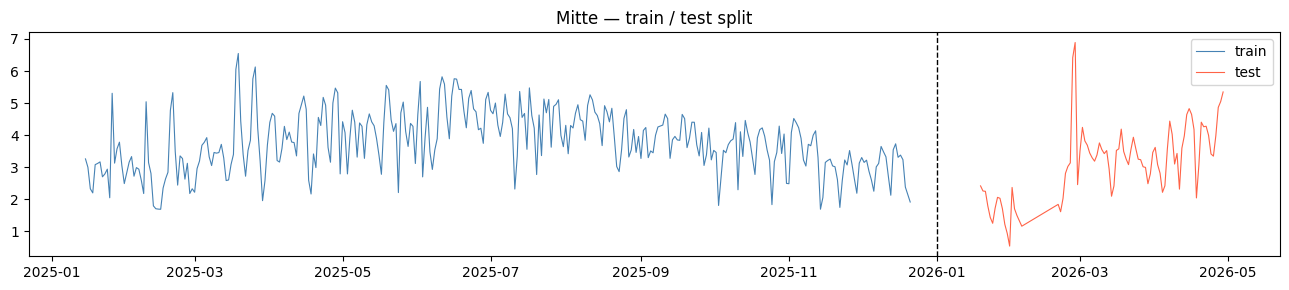

In [5]:
# Visualise split on Mitte
mitte = df[df['district'] == 'Mitte'].sort_values('date')

fig, ax = plt.subplots(figsize=(13, 3))
ax.plot(mitte.loc[mitte['date'] < SPLIT_DATE, 'date'],
        mitte.loc[mitte['date'] < SPLIT_DATE, TARGET],
        color='steelblue', linewidth=0.8, label='train')
ax.plot(mitte.loc[mitte['date'] >= SPLIT_DATE, 'date'],
        mitte.loc[mitte['date'] >= SPLIT_DATE, TARGET],
        color='tomato', linewidth=0.8, label='test')
ax.axvline(SPLIT_DATE, color='black', linestyle='--', linewidth=1)
ax.set_title('Mitte — train / test split')
ax.legend()
plt.tight_layout()
plt.show()

## 3. Baseline — Naive lag_7d Forecast

Predict tomorrow's demand as the same day last week.  
This is the minimum bar the model must beat to be useful.

In [6]:
baseline_pred = test['lag_7d']

baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
baseline_mae  = mean_absolute_error(y_test, baseline_pred)
baseline_r2   = r2_score(y_test, baseline_pred)

print(f'Baseline (lag_7d)  RMSE: {baseline_rmse:.1f}   MAE: {baseline_mae:.1f}   R²: {baseline_r2:.3f}')

Baseline (lag_7d)  RMSE: 1.0   MAE: 0.6   R²: 0.425


## 4. LightGBM + MLflow

First run: reasonable defaults, no hyperparameter tuning yet.  
Early stopping on the test RMSE prevents overfitting.

In [7]:
mlflow.set_tracking_uri('sqlite:///../mlflow.db')
mlflow.set_experiment('berlin-bike-demand')

params = {
    'objective'       : 'regression',
    'metric'          : ['rmse', 'mae'],
    'num_leaves'      : 63,
    'learning_rate'   : 0.05,
    'n_estimators'    : 1000,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq'    : 5,
    'min_child_samples': 20,
    'verbose'         : -1,
    'random_state'    : 42,
}

In [8]:
with mlflow.start_run(run_name='lgbm-relative-demand') as run:
    mlflow.log_params(params)
    mlflow.log_param('split_date', str(SPLIT_DATE.date()))
    mlflow.log_param('target', TARGET)
    mlflow.log_param('n_train', len(X_train))
    mlflow.log_param('n_test', len(X_test))
    mlflow.log_param('excluded_districts', str(LOW_DEMAND_DISTRICTS))

    model = lgb.LGBMRegressor(**params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_train, y_train), (X_test, y_test)],
        eval_names=['train', 'test'],
        callbacks=[
            lgb.early_stopping(50, verbose=False),
            lgb.log_evaluation(100),
        ],
        categorical_feature=['district'],
    )

    y_pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)

    # Also evaluate in absolute rentals: predicted_rel * active_stations ≈ rentals_tomorrow
    y_pred_abs = y_pred * test['active_stations']
    y_test_abs = test['rentals_tomorrow']
    rmse_abs = np.sqrt(mean_squared_error(y_test_abs, y_pred_abs))
    mae_abs  = mean_absolute_error(y_test_abs, y_pred_abs)

    mlflow.log_metrics({
        'test_rmse'         : rmse,
        'test_mae'          : mae,
        'test_r2'           : r2,
        'test_rmse_abs'     : rmse_abs,
        'test_mae_abs'      : mae_abs,
        'baseline_rmse'     : baseline_rmse,
        'baseline_mae'      : baseline_mae,
        'best_iteration'    : model.best_iteration_,
    })

    mlflow.lightgbm.log_model(model.booster_, 'model')
    run_id = run.info.run_id

print(f'\n--- Relative demand (model target) ---')
print(f'LightGBM  RMSE: {rmse:.3f}   MAE: {mae:.3f}   R²: {r2:.3f}   (best iter: {model.best_iteration_})')
print(f'Baseline  RMSE: {baseline_rmse:.3f}   MAE: {baseline_mae:.3f}   R²: {baseline_r2:.3f}')
print(f'\n--- Absolute rentals (operational) ---')
print(f'LightGBM  RMSE: {rmse_abs:.1f}   MAE: {mae_abs:.1f}')
print(f'\nMLflow run ID: {run_id}')

[100]	train's rmse: 0.23713	train's l1: 0.170787	test's rmse: 0.701381	test's l1: 0.436206


2026/06/03 15:43:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



--- Relative demand (model target) ---
LightGBM  RMSE: 0.699   MAE: 0.434   R²: 0.704   (best iter: 113)
Baseline  RMSE: 0.973   MAE: 0.638   R²: 0.425

--- Absolute rentals (operational) ---
LightGBM  RMSE: 230.6   MAE: 119.3

MLflow run ID: 433b6fdad7cf4096a5951d60cf38db29


## 5. Evaluation

In [9]:
# Per-district metrics — relative demand (model target)
rows = []
for district, grp in test.groupby('district'):
    preds     = model.predict(grp[FEATURE_COLS])
    preds_abs = preds * grp['active_stations']
    rows.append({
        'district'         : str(district),
        'n'                : len(grp),
        'rmse_rel'         : np.sqrt(mean_squared_error(grp[TARGET], preds)),
        'r2_rel'           : r2_score(grp[TARGET], preds),
        'rmse_abs'         : np.sqrt(mean_squared_error(grp['rentals_tomorrow'], preds_abs)),
        'mae_abs'          : mean_absolute_error(grp['rentals_tomorrow'], preds_abs),
        'baseline_rmse_abs': np.sqrt(mean_squared_error(grp['rentals_tomorrow'], grp['lag_7d'] * grp['active_stations'])),
    })

dm = pd.DataFrame(rows).sort_values('rmse_abs', ascending=False)
dm['rmse_abs_vs_baseline'] = dm['rmse_abs'] - dm['baseline_rmse_abs']
print(dm.to_string(index=False))

                  district  n  rmse_rel  r2_rel  rmse_abs  mae_abs  baseline_rmse_abs  rmse_abs_vs_baseline
                     Mitte 86      0.83    0.48    474.23   333.57             686.88               -212.66
  Friedrichshain-Kreuzberg 86      1.09    0.48    407.43   262.41             543.42               -135.99
                  Neukölln 86      1.04    0.43    169.33   102.40             231.56                -62.23
                    Pankow 86      0.62    0.36    121.72    72.84             154.72                -33.00
      Tempelhof-Schöneberg 86      0.54    0.36    112.08    73.35             151.78                -39.70
Charlottenburg-Wilmersdorf 86      0.42    0.41    109.42    78.29             143.24                -33.82
          Treptow-Köpenick 86      0.58    0.25    101.41    68.45             119.77                -18.35
               Lichtenberg 86      0.38    0.49     92.68    62.16             105.77                -13.09
       Steglitz-Zehlendorf 8

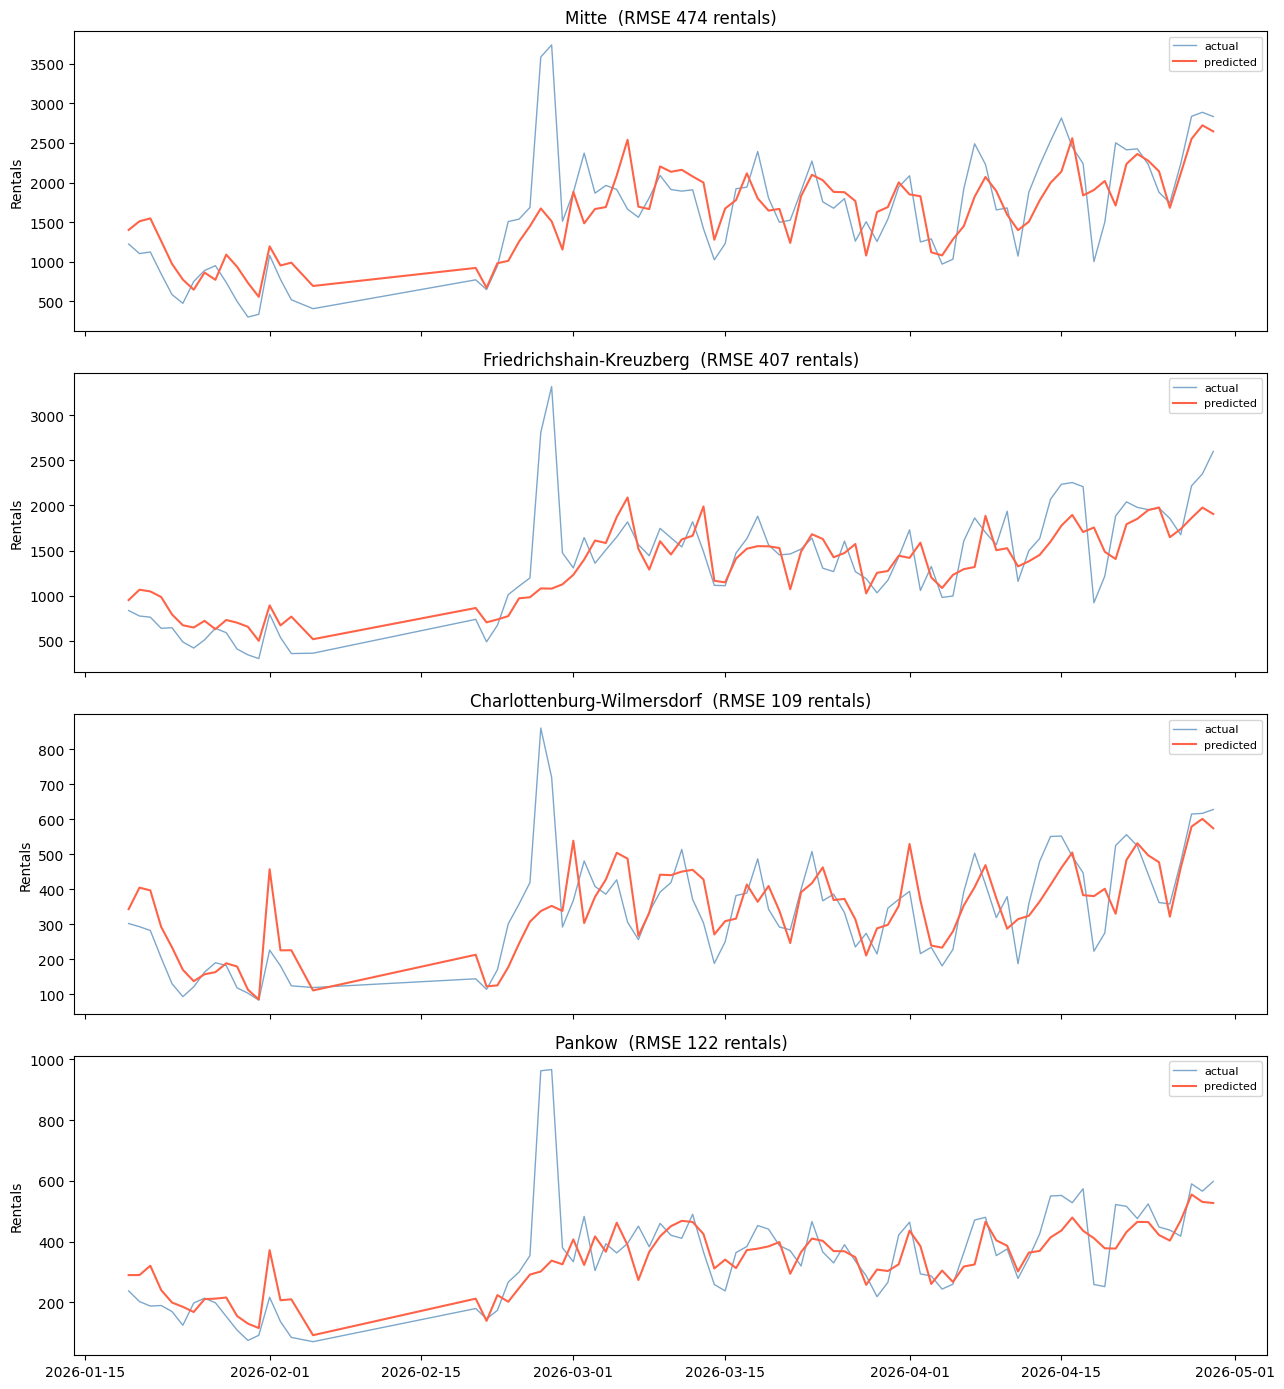

In [10]:
# Predictions vs actual in absolute rentals for the top 4 districts
top_districts = ['Mitte', 'Friedrichshain-Kreuzberg', 'Charlottenburg-Wilmersdorf', 'Pankow']

fig, axes = plt.subplots(len(top_districts), 1, figsize=(13, 14), sharex=True)
for ax, district in zip(axes, top_districts):
    grp       = test[test['district'] == district].sort_values('date')
    preds_abs = model.predict(grp[FEATURE_COLS]) * grp['active_stations']
    actual    = grp['rentals_tomorrow']
    d_rmse    = np.sqrt(mean_squared_error(actual, preds_abs))
    ax.plot(grp['date'], actual,    color='steelblue', linewidth=1, alpha=0.7, label='actual')
    ax.plot(grp['date'], preds_abs, color='tomato',    linewidth=1.5,          label='predicted')
    ax.set_title(f'{district}  (RMSE {d_rmse:.0f} rentals)')
    ax.set_ylabel('Rentals')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 6. Feature Importance

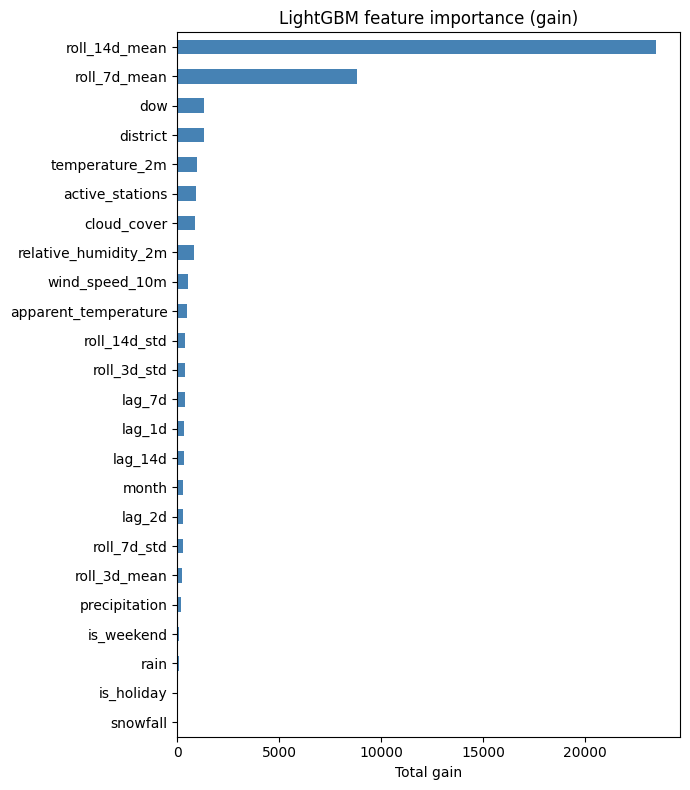

roll_14d_mean          23501.88
roll_7d_mean            8798.56
dow                     1304.82
district                1281.92
temperature_2m           952.64
active_stations          908.76
cloud_cover              848.88
relative_humidity_2m     823.71
wind_speed_10m           523.48
apparent_temperature     457.43
roll_14d_std             388.17
roll_3d_std              381.67
lag_7d                   351.82
lag_1d                   342.87
lag_14d                  312.64
month                    256.67
lag_2d                   253.05
roll_7d_std              248.62
roll_3d_mean             221.02
precipitation            188.16
is_weekend                92.67
rain                      55.30
is_holiday                15.56
snowfall                  13.34


In [11]:
importance = pd.Series(
    model.booster_.feature_importance(importance_type='gain'),
    index=FEATURE_COLS,
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(7, 8))
importance.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('LightGBM feature importance (gain)')
ax.set_xlabel('Total gain')
plt.tight_layout()
plt.show()

print(importance.sort_values(ascending=False).to_string())

## 7. Optuna Hyperparameter Optimisation

TPE sampler searches `num_leaves`, `learning_rate`, regularisation, and subsampling parameters.
Each trial trains a LightGBM model with early stopping and returns test RMSE on relative demand.
The best params are then logged to MLflow as a separate run for comparison.

In [12]:
def objective(trial):
    params = {
        'objective'        : 'regression',
        'metric'           : 'rmse',
        'verbose'          : -1,
        'random_state'     : 42,
        'n_estimators'     : 1000,
        'num_leaves'       : trial.suggest_int('num_leaves', 20, 500),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'feature_fraction' : trial.suggest_float('feature_fraction', 0.5, 1.0),
        'bagging_fraction' : trial.suggest_float('bagging_fraction', 0.5, 1.0),
        'bagging_freq'     : trial.suggest_int('bagging_freq', 1, 7),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'reg_alpha'        : trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda'       : trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
    }

    m = lgb.LGBMRegressor(**params)
    m.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        callbacks=[
            lgb.early_stopping(50, verbose=False),
            lgb.log_evaluation(-1),
        ],
        categorical_feature=['district'],
    )
    return np.sqrt(mean_squared_error(y_test, m.predict(X_test)))

In [13]:
N_TRIALS = 50

study = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=42),
    study_name='lgbm-berlin-bike',
)
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print(f'\nBest RMSE (relative demand): {study.best_value:.4f}')
print(f'Best params:')
for k, v in study.best_params.items():
    print(f'  {k}: {v}')

Best trial: 25. Best value: 0.668236: 100%|████████████████| 50/50 [00:43<00:00,  1.16it/s]


Best RMSE (relative demand): 0.6682
Best params:
  num_leaves: 500
  learning_rate: 0.05886206710037451
  feature_fraction: 0.8412005808906498
  bagging_fraction: 0.6894850472344325
  bagging_freq: 1
  min_child_samples: 72
  reg_alpha: 2.7415521161467403e-05
  reg_lambda: 0.06380114956594062


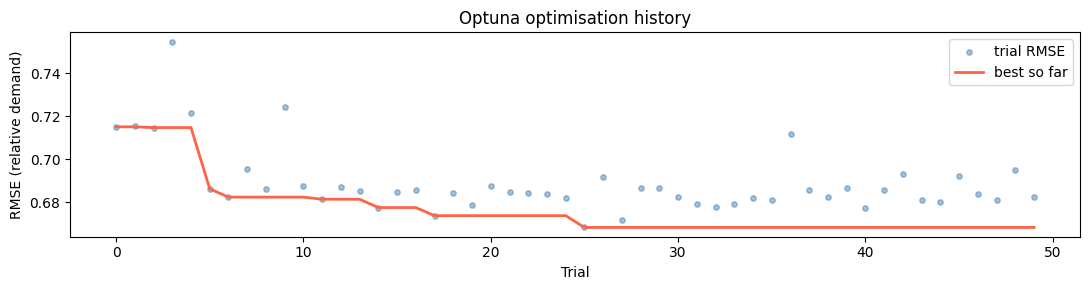

In [14]:
# Optimisation history: how RMSE improved across trials
trials_df = study.trials_dataframe().sort_values('number')

fig, ax = plt.subplots(figsize=(11, 3))
ax.scatter(trials_df['number'], trials_df['value'], s=15, alpha=0.5, color='steelblue', label='trial RMSE')
ax.plot(trials_df['number'], trials_df['value'].cummin(), color='tomato', linewidth=2, label='best so far')
ax.set_xlabel('Trial')
ax.set_ylabel('RMSE (relative demand)')
ax.set_title('Optuna optimisation history')
ax.legend()
plt.tight_layout()
plt.show()

In [15]:
# Train the best model and log to MLflow
best_params = {
    'objective'    : 'regression',
    'metric'       : ['rmse', 'mae'],
    'verbose'      : -1,
    'random_state' : 42,
    'n_estimators' : 1000,
    **study.best_params,
}

with mlflow.start_run(run_name='lgbm-optuna-best') as run:
    mlflow.log_params(best_params)
    mlflow.log_param('target', TARGET)
    mlflow.log_param('n_trials', N_TRIALS)
    mlflow.log_param('excluded_districts', str(LOW_DEMAND_DISTRICTS))

    best_model = lgb.LGBMRegressor(**best_params)
    best_model.fit(
        X_train, y_train,
        eval_set=[(X_train, y_train), (X_test, y_test)],
        eval_names=['train', 'test'],
        callbacks=[
            lgb.early_stopping(50, verbose=False),
            lgb.log_evaluation(100),
        ],
        categorical_feature=['district'],
    )

    y_pred_opt     = best_model.predict(X_test)
    y_pred_opt_abs = y_pred_opt * test['active_stations']

    rmse_opt     = np.sqrt(mean_squared_error(y_test, y_pred_opt))
    mae_opt      = mean_absolute_error(y_test, y_pred_opt)
    r2_opt       = r2_score(y_test, y_pred_opt)
    rmse_opt_abs = np.sqrt(mean_squared_error(test['rentals_tomorrow'], y_pred_opt_abs))
    mae_opt_abs  = mean_absolute_error(test['rentals_tomorrow'], y_pred_opt_abs)

    mlflow.log_metrics({
        'test_rmse'     : rmse_opt,
        'test_mae'      : mae_opt,
        'test_r2'       : r2_opt,
        'test_rmse_abs' : rmse_opt_abs,
        'test_mae_abs'  : mae_opt_abs,
        'baseline_rmse' : baseline_rmse,
        'best_iteration': best_model.best_iteration_,
    })
    mlflow.lightgbm.log_model(best_model.booster_, 'model')
    best_run_id = run.info.run_id

print(f'--- Relative demand ---')
print(f'Baseline   RMSE: {baseline_rmse:.3f}')
print(f'Default    RMSE: {rmse:.3f}')
print(f'Optuna     RMSE: {rmse_opt:.3f}   MAE: {mae_opt:.3f}   R²: {r2_opt:.3f}   (best iter: {best_model.best_iteration_})')
print(f'\n--- Absolute rentals ---')
print(f'Default    RMSE: {rmse_abs:.1f}   MAE: {mae_abs:.1f}')
print(f'Optuna     RMSE: {rmse_opt_abs:.1f}   MAE: {mae_opt_abs:.1f}')
print(f'\nMLflow run ID: {best_run_id}')

2026/06/03 15:44:29 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


[100]	train's rmse: 0.384742	train's l1: 0.2677	test's rmse: 0.676372	test's l1: 0.406187
--- Relative demand ---
Baseline   RMSE: 0.973
Default    RMSE: 0.699
Optuna     RMSE: 0.677   MAE: 0.406   R²: 0.722   (best iter: 94)

--- Absolute rentals ---
Default    RMSE: 230.6   MAE: 119.3
Optuna     RMSE: 225.7   MAE: 112.7

MLflow run ID: d436116622c3401ca2c901fb4dde899a


In [16]:
# Save the best model to disk for Streamlit and API use
model_path = MODELS_DIR / 'best_model.txt'
best_model.booster_.save_model(str(model_path))
print(f'Model saved to {model_path}')

Model saved to ../models/best_model.txt


## View results in MLflow UI

Run this from the project root to open the experiment dashboard:

```bash
mlflow ui --backend-store-uri sqlite:///mlflow.db
```

Then open http://localhost:5000 in your browser.